In [1]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np 
import random
import torchvision 
import torch.nn.functional as functional

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

torch.manual_seed(32)
torch.cuda.manual_seed(32)
random.seed(42)

cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std = [0.2023, 0.1994, 0.2010]

train_transformer = transforms.Compose([
transforms.RandomCrop(32, padding=4),    
transforms.RandomHorizontalFlip(),
transforms.RandAugment(num_ops=2, magnitude=9),
transforms.ToTensor(),
transforms.Normalize(cifar10_mean, cifar10_std),
    
])

train_dataset = datasets.CIFAR10(root="cifar10_data", train=True, download = True, transform = train_transformer)

# Load Testing Data 

test_transformer = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(cifar10_mean, cifar10_std)
])

test_dataset = datasets.CIFAR10(root="cifar10_data", train=False, download = True, transform = test_transformer)

cuda


In [2]:
#DataLoaders

dataloader_train = DataLoader(train_dataset, batch_size=128, shuffle=True)
dataloader_test = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"TRAIN DATALOADER : {len(dataloader_train)} batches")
print(f"TEST DATALOADER : {len(dataloader_test)} batches")

TRAIN DATALOADER : 391 batches
TEST DATALOADER : 79 batches


In [3]:
num_classes=10
output_size = 100352
print(output_size)

class CustomCNN(nn.Module):
    def __init__(self, use_bn=False, *args, **kwargs):
        super(CustomCNN, self).__init__()
        num_classes=10
       
        self.counter=0
        self.features = nn.Sequential(
            nn.Conv2d(3,64,3, 1 , 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2, 0, 1, ceil_mode=False),
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2, 0, 1, ceil_mode=False),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2, 0, 1, ceil_mode=False)
        )

        # with torch.no_grad():
         #   dummy = torch.zeros(1, 3, 32, 32)
          #  out = self.features(dummy)
           # output_size = out.view(1, -1).size(1)
        
        self.classifier = nn.Sequential(
            nn.Linear(2048 , 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 512),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # (batch, 128, 4, 4) ->  (batch, 128 * 4 * 4) = (batch, 2048) 1 means 1st dim 
        x = self.classifier(x)
        return x


100352


In [4]:
train_acc_list = []
val_acc_list = []
import matplotlib.pyplot as plt

# Weight Initialization for CNN Models ,  Kaiming (He) initialization
def initialize_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

model = CustomCNN()
model.to(device)
model.apply(initialize_weights)
print(model.features)
print(model.classifier)
print("TRAINING with Cosine LR Scheduler ")
epochs = 10


# Training

def train(model, loader : DataLoader, optimizer, loss_function):
    model.train()
    correct, total_loss = 0, 0  
    for img_batch, labels in loader:
        img_batch = img_batch.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(img_batch)
        loss = loss_function(output, labels)
        loss.backward() # Back Prop 
        optimizer.step() # gradient Descent
        total_loss+= loss.item() * img_batch.size(0)
        correct+= (output.argmax(1)==labels).sum().item()
    return total_loss/len(loader.dataset) , correct/len(loader.dataset)  


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
Sequential(
  (0): Linear(in_features=2048, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=512, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout

In [5]:
# Evaluation
def evaluate_model(model, loader : DataLoader):
    model.eval()
    correct = 0
    with torch.inference_mode():
        for img_batch, labels in loader:
            img_batch = img_batch.to(device)
            labels = labels.to(device)
            output = model(img_batch)
            predictions = output.argmax(dim=1)
            correct+= (predictions==labels).sum().item()
        return correct/len(loader.dataset)    

In [6]:

train_accuracies, test_accuracies = [], []
EPOCHS=100
# Cross Entropy Loss and AdamW Optimizer 
loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(params=model.parameters(), lr=1e-4, betas=(0.9, 0.999), weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, dataloader_train, optimizer, loss_function)
    test_acc = evaluate_model(model, dataloader_test)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch : {epoch+1} of {EPOCHS}, Train Loss : {train_loss:.4f} , Train Accuracy : {train_acc:.4f}, Test Accuracy : {test_acc:.4f}")
    scheduler.step() 

Epoch : 1 of 100, Train Loss : 1.9721 , Train Accuracy : 0.2704, Test Accuracy : 0.4475
Epoch : 2 of 100, Train Loss : 1.6430 , Train Accuracy : 0.4011, Test Accuracy : 0.5184
Epoch : 3 of 100, Train Loss : 1.4950 , Train Accuracy : 0.4592, Test Accuracy : 0.5665
Epoch : 4 of 100, Train Loss : 1.3898 , Train Accuracy : 0.5005, Test Accuracy : 0.6020
Epoch : 5 of 100, Train Loss : 1.3082 , Train Accuracy : 0.5331, Test Accuracy : 0.6438
Epoch : 6 of 100, Train Loss : 1.2258 , Train Accuracy : 0.5648, Test Accuracy : 0.6589
Epoch : 7 of 100, Train Loss : 1.1530 , Train Accuracy : 0.5913, Test Accuracy : 0.6892
Epoch : 8 of 100, Train Loss : 1.0989 , Train Accuracy : 0.6084, Test Accuracy : 0.6957
Epoch : 9 of 100, Train Loss : 1.0636 , Train Accuracy : 0.6268, Test Accuracy : 0.7012
Epoch : 10 of 100, Train Loss : 1.0184 , Train Accuracy : 0.6421, Test Accuracy : 0.7279
Epoch : 11 of 100, Train Loss : 0.9788 , Train Accuracy : 0.6569, Test Accuracy : 0.7264
Epoch : 12 of 100, Train Loss 

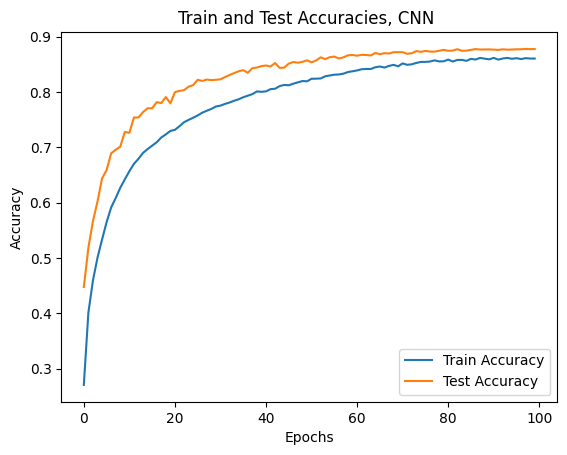

In [10]:
plt.plot(train_accuracies, label = "Train Accuracy")
plt.plot(test_accuracies, label = "Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train and Test Accuracies, CNN ")
plt.savefig("CNN-CIFAR10.png",  dpi=300)
plt.show()

In [8]:
torch.save(model, 'CNN_Cifar10_AdamW.pth')

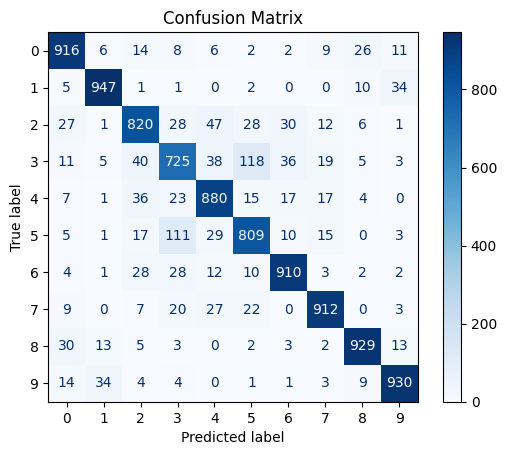

Test Accuracy: 0.88%
Precision: 0.88
Recall:    0.88
F1 Score:  0.88


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('CNN_Cifar10_AdamW.pth', weights_only=False)

def test_model(model, loader : DataLoader):
    model.eval()
    correct = 0
    all_labels = []
    all_predictions = []
    with torch.inference_mode():
        for img_batch, labels in loader:
            img_batch = img_batch.to(device)
            labels = labels.to(device)
            output = model(img_batch)
            predictions = output.argmax(dim=1)
            correct+= (predictions==labels).sum().item()
            all_labels.extend(labels.to("cpu").numpy())
            all_predictions.extend(predictions.to("cpu").numpy())
        return correct/len(loader.dataset), all_labels, all_predictions   

test_accuracy, all_labels, all_predictions = test_model(model, dataloader_test)
        
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig("CNNCIFAR10ConfusionMatrix.png",  dpi=300)
plt.show()
print(f"Test Accuracy: {test_acc:.2f}%")
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
 